In [12]:
# Proyecto Data Warehouse - Sakila con ClickHouse

#Estudiante: Sofia Oxford, 15001860  
#Fecha: Abril 2026  

# Este notebook en Python muestra el análisis realizado sobre la base de datos Sakila utilizando un Data Warehouse en ClickHouse para el proyecto final DW 2026.

# Estas fueron las capas implementadas:
# Se utilizó Bronze: Copia desde MySQL
# Capa Silver para visualización y combinaciones de datos
# Capa Gold: Para realizar el esquema estrella que incluye la tabla de hechos y las tablas de dimensiones. 

# Finalmente, se responden las 5 preguntas de negocio utilizando Python + ClickHouse.

In [11]:
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Conexión a ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username='default',
    password='Carrotito10.'
)

In [13]:
print("Se explora la capa de bronce")

tables = ['film', 'customer', 'rental', 'payment', 'actor', 'inventory']

for table in tables:
    query = f"SELECT COUNT(*) as total FROM sakila_bronze.{table}"
    result = client.query_df(query)
    print(f"Tabla sakila_bronze.{table}: {result['total'].iloc[0]:,} registros")

Se explora la capa de bronce
Tabla sakila_bronze.film: 1,000 registros
Tabla sakila_bronze.customer: 599 registros
Tabla sakila_bronze.rental: 16,044 registros
Tabla sakila_bronze.payment: 16,044 registros
Tabla sakila_bronze.actor: 200 registros
Tabla sakila_bronze.inventory: 4,581 registros


In [ ]:
print("Se realiza una exploración de la capa Silver")

query_silver = """
SELECT
    title,
    customer_name,
    amount,
    payment_date
FROM sakila_silver.payments_enriched
LIMIT 10
"""

df_silver = client.query_df(query_silver)
df_silver

=== EXPLORANDO LA CAPA SILVER ===


,title,customer_name,amount,payment_date
0,PATIENT SISTER,MARY SMITH,2.99,2005-05-25 11:30:37
1,TALENTED HOMICIDE,MARY SMITH,0.99,2005-05-28 10:35:23
2,MUSKETEERS WAIT,MARY SMITH,5.99,2005-06-15 00:54:12
3,DETECTIVE VISION,MARY SMITH,0.99,2005-06-15 18:02:53
4,FERRIS MOTHER,MARY SMITH,9.99,2005-06-15 21:08:46
5,CLOSER BANG,MARY SMITH,4.99,2005-06-16 15:18:57
6,ATTACKS HATE,MARY SMITH,4.99,2005-06-18 08:41:48
7,SAVANNAH TOWN,MARY SMITH,0.99,2005-06-18 13:33:59
8,YOUTH KICK,MARY SMITH,3.99,2005-06-21 06:24:45
9,FIRE WOLVES,MARY SMITH,5.99,2005-07-08 03:17:05


In [25]:
print("Explorando la capa Gold resolviendo las preguntas de negocio")

# 1. Top 10 películas más rentadas
q1 = """
SELECT
    f.title AS pelicula,
    COUNT(*) AS veces_rentada
FROM sakila_gold.fact_rentals r
JOIN sakila_gold.dim_film f
    ON r.film_id = f.film_id
GROUP BY f.title
ORDER BY veces_rentada DESC
LIMIT 10
"""
df1 = client.query_df(q1)
print("1. Top 10 películas más rentadas:")
display(df1)

# 2. Top 5 países con más rentas
q2 = """
SELECT
    c.country,
    COUNT(*) AS total_rentas
FROM sakila_gold.fact_rentals r
JOIN sakila_gold.dim_customer c
    ON r.customer_id = c.customer_id
GROUP BY c.country
ORDER BY total_rentas DESC
LIMIT 5
"""
df2 = client.query_df(q2)
print("\n2. Top 5 países con más rentas:")
display(df2)

# 3. Top 10 clientes que más han pagado
q3 = """
SELECT
    c.customer_name AS cliente,
    SUM(r.amount) AS monto_total
FROM sakila_gold.fact_rentals r
JOIN sakila_gold.dim_customer c
    ON r.customer_id = c.customer_id
GROUP BY c.customer_name
ORDER BY monto_total DESC
LIMIT 10
"""
df3 = client.query_df(q3)
print("\n3. Top 10 clientes que más han pagado:")
display(df3)

# 4. Top 5 actores con más rentas
q4 = """
SELECT
    a.actor_name AS actor,
    COUNT(*) AS total_rentas
FROM sakila_gold.fact_rentals r
JOIN sakila_gold.bridge_film_actor bfa
    ON r.film_id = bfa.film_id
JOIN sakila_gold.dim_actor a
    ON bfa.actor_id = a.actor_id
GROUP BY a.actor_name
ORDER BY total_rentas DESC
LIMIT 5
"""
df4 = client.query_df(q4)
print("\n4. Top 5 actores con más rentas:")
display(df4)

# 5. Ingresos por mes
q5 = """
SELECT
    formatDateTime(payment_date, '%Y-%m') AS mes,
    SUM(amount) AS monto_total
FROM sakila_gold.fact_rentals
GROUP BY mes
ORDER BY mes
"""
df5 = client.query_df(q5)
print("\n5. Ingresos por mes:")
display(df5)

Explorando la capa Gold resolviendo las preguntas de negocio
1. Top 10 películas más rentadas:


,pelicula,veces_rentada
0,BUCKET BROTHERHOOD,34
1,ROCKETEER MOTHER,33
2,GRIT CLOCKWORK,32
3,SCALAWAG DUCK,32
4,JUGGLER HARDLY,32
5,RIDGEMONT SUBMARINE,32
6,FORWARD TEMPLE,32
7,APACHE DIVINE,31
8,RUSH GOODFELLAS,31
9,TIMBERLAND SKY,31



2. Top 5 países con más rentas:


,country,total_rentas
0,India,1572
1,China,1426
2,United States,968
3,Japan,825
4,Mexico,796



3. Top 10 clientes que más han pagado:


,cliente,monto_total
0,KARL SEAL,221.55
1,ELEANOR HUNT,216.54
2,CLARA SHAW,195.58
3,MARION SNYDER,194.61
4,RHONDA KENNEDY,194.61
5,TOMMY COLLAZO,186.62
6,WESLEY BULL,177.60
7,TIM CARY,175.61
8,MARCIA DEAN,175.58
9,ANA BRADLEY,174.66



4. Top 5 actores con más rentas:


,actor,total_rentas
0,SUSAN DAVIS,825
1,GINA DEGENERES,753
2,MATTHEW CARREY,678
3,MARY KEITEL,674
4,ANGELA WITHERSPOON,654



5. Ingresos por mes:


,mes,monto_total
0,2005-05,4823.44
1,2005-06,9629.89
2,2005-07,28368.91
3,2005-08,24070.14
4,2006-02,514.18


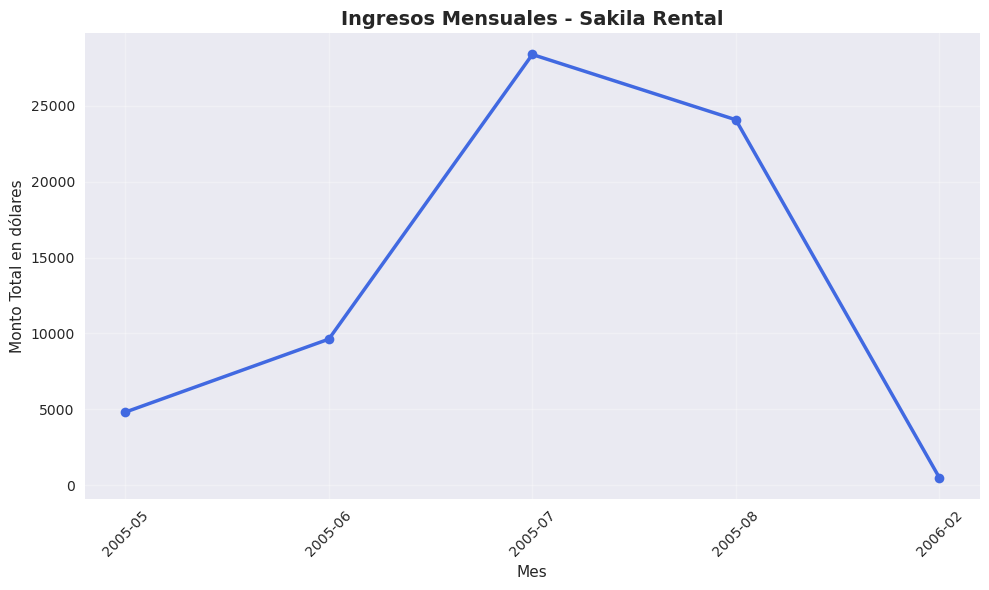

/tmp/ipykernel_3337/1008336103.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df1.head(10), x='veces_rentada', y='pelicula', palette='viridis')


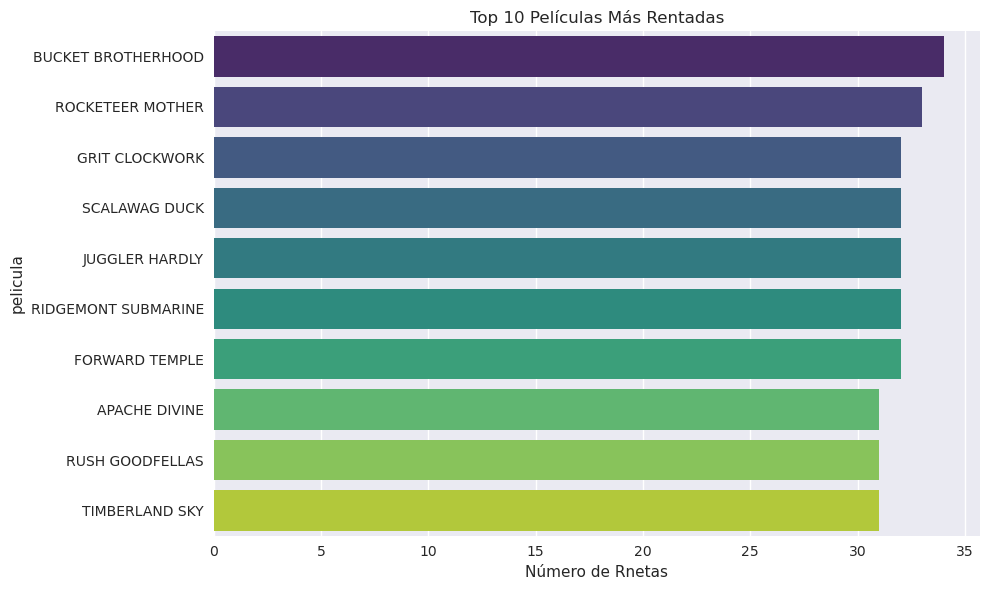

In [27]:
# Gráfico 1: Ingresos por mes
plt.figure(figsize=(10, 6))
plt.plot(df5['mes'], df5['monto_total'], marker='o', linewidth=2.5, color='royalblue')
plt.title('Ingresos Mensuales - Sakila Rental', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Monto Total en dólares')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Top 10 películas
plt.figure(figsize=(10, 6))
sns.barplot(data=df1.head(10), x='veces_rentada', y='pelicula', palette='viridis')
plt.title('Top 10 Películas Más Rentadas')
plt.xlabel('Número de Rnetas')
plt.tight_layout()
plt.show()